# 05 — Comparative Evaluation

Compare all three models side-by-side using the saved metric JSON files. This
is the notebook that produces the master comparison table reported in §5 of
the final report.


In [1]:
# Path-setup boilerplate so the notebook can import src.*
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("project root:", ROOT)


project root: /Users/spandarayamajhi/Desktop/Artificial Intelligence Coursework (Final Submission)


In [2]:
import json, pandas as pd
from src import config


## 1. Load all three metric bundles

In [3]:
files = {
    'TF-IDF + LR'       : 'tfidf_lr_metrics.json',
    'DistilBERT'        : 'distilbert_metrics.json',
    'Retrieval-Enhanced': 'retrieval_enhanced_metrics.json',
}
rows = []
for name, f in files.items():
    p = config.RESULTS_DIR / f
    if not p.exists():
        print(f'!! missing {p.name}'); continue
    d = json.loads(p.read_text())
    rows.append({
        'model': name,
        'accuracy': round(d['accuracy'], 4),
        'precision': round(d['precision'], 4),
        'recall': round(d['recall'], 4),
        'f1': round(d['f1'], 4),
        'macro_f1': round(d['macro_f1'], 4),
        'roc_auc': round(d['roc_auc'], 4) if d['roc_auc'] else None,
    })
table = pd.DataFrame(rows)
table


,model,accuracy,precision,recall,f1,macro_f1,roc_auc
0,TF-IDF + LR,0.8794,0.8817,0.8302,0.8552,0.8759,0.9485
1,DistilBERT,0.7338,0.7167,0.6268,0.6687,0.7231,0.7964
2,Retrieval-Enhanced,0.7113,0.6918,0.5889,0.6362,0.6984,0.7804


## 2. Plots

In [4]:
from src import visualizations as viz
viz.plot_model_comparison([{
    'model': r['model'], 'accuracy': r['accuracy'],
    'precision': r['precision'], 'recall': r['recall'],
    'f1': r['f1'], 'macro_f1': r['macro_f1']
} for r in rows])


PosixPath('/Users/spandarayamajhi/Desktop/Artificial Intelligence Coursework (Final Submission)/outputs/figures/fig_model_comparison.png')

In [5]:
viz.plot_f1_comparison([{
    'model': r['model'], 'f1': r['f1']
} for r in rows])


/Users/spandarayamajhi/Desktop/Artificial Intelligence Coursework (Final Submission)/src/visualizations.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x="model", y="f1", ax=ax, palette="crest")


PosixPath('/Users/spandarayamajhi/Desktop/Artificial Intelligence Coursework (Final Submission)/outputs/figures/fig_f1_comparison.png')

## 3. α-ablation (retrieval-weight sweep)

In [6]:
ab = pd.read_csv(config.RESULTS_DIR / 'retrieval_alpha_ablation.csv')
ab


,alpha,accuracy,f1,macro_f1
0,0.0,0.61750,0.559078,0.610665
1,0.3,0.65750,0.589820,0.647914
2,0.5,0.70625,0.632238,0.693850
3,0.7,0.71125,0.636220,0.698421
4,0.9,0.73375,0.668740,0.723085
5,1.0,0.73375,0.668740,0.723085


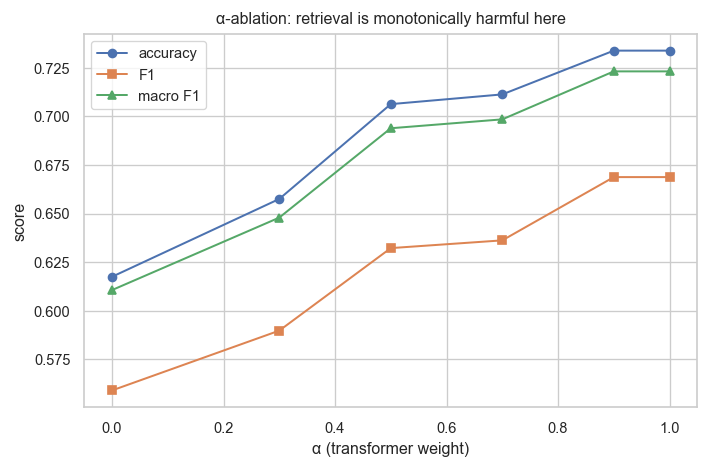

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(ab['alpha'], ab['accuracy'], 'o-', label='accuracy')
ax.plot(ab['alpha'], ab['f1'], 's-', label='F1')
ax.plot(ab['alpha'], ab['macro_f1'], '^-', label='macro F1')
ax.set_xlabel('α (transformer weight)'); ax.set_ylabel('score')
ax.set_title('α-ablation: retrieval is monotonically harmful here')
ax.legend(); plt.tight_layout(); plt.show()


The curve is monotonically increasing in α: more transformer weight always
helps, more retrieval weight always hurts. This *contradicts* the working
hypothesis (retrieval should help) and is the headline negative result of
the project. Discussion of why is in §6 of the final report — the short
version is *label-lexicon leakage*: under weak labels, neighbour pools carry
the same heuristic noise as the query, so soft-voting amplifies error.
